In [1]:
#pip install tensorflow

In [2]:
#import tensorflow as tf

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("Datasets/Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
data.shape

(10000, 14)

In [7]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### No null values are present

In [9]:
data.drop(['RowNumber', 'CustomerId','Surname'], axis = 1, inplace=True)

In [10]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### Find outliers

In [11]:
def findOutliers(data, col):
    plt.figure(figsize = (10,5))
    plt.subplot(1, 2, 1)
    plt.boxplot(data[col])
    mean = data[col].mean()
    std = data[col].std()
    plt.subplot(1, 2, 2)
    sns.histplot(data, x = col, kde = True)
    plt.axvline(mean + 3 * std)
    plt.axvline(mean - 3 * std)

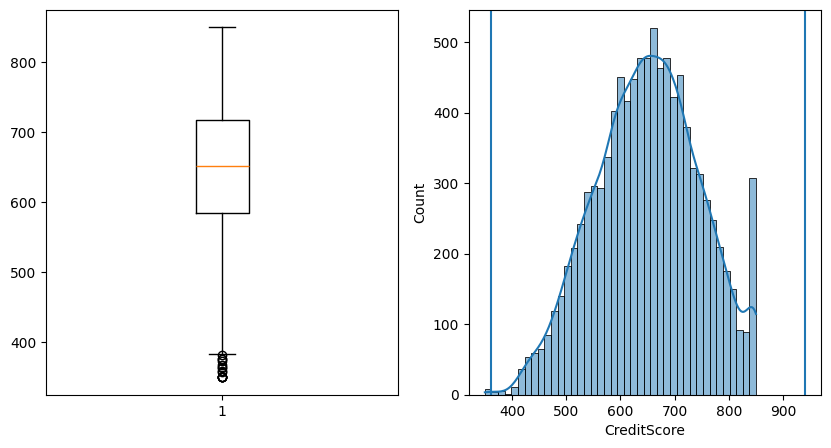

In [12]:
findOutliers(data, 'CreditScore')

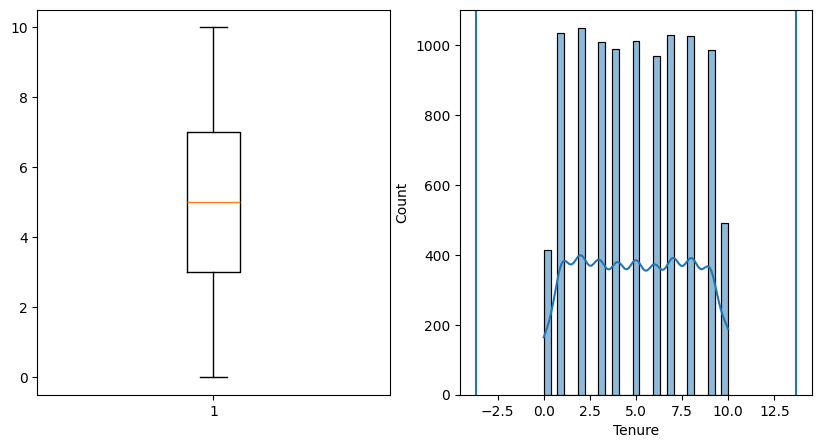

In [13]:
findOutliers(data, 'Tenure')

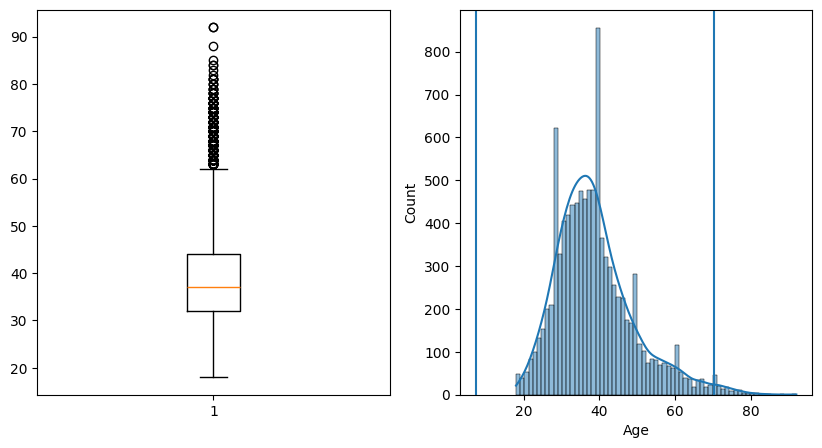

In [14]:
findOutliers(data, 'Age')

In [15]:
# function for show outliers
def showOutliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + (1.5 * iqr)
    lower = q1 - (1.5 * iqr)
    # print("Upper : " ,upper)
    # print("Lower : ", lower)
    return data[(data[col] < lower) | (data[col] > upper)]
    

In [16]:
showOutliers(data, 'CreditScore')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1405,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
2579,365,Germany,Male,30,0,127760.07,1,1,0,81537.85,1
8154,367,Spain,Male,42,6,93608.28,1,1,0,168816.73,1


In [17]:
showOutliers(data, 'Tenure')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [18]:
showOutliers(data, 'Age')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
58,511,Spain,Female,66,4,0.00,1,1,0,1643.11,1
85,652,Spain,Female,75,10,0.00,2,1,1,114675.75,0
104,670,Spain,Female,65,1,0.00,1,1,1,177655.68,1
158,646,France,Female,73,6,97259.25,1,0,1,104719.66,0
181,510,France,Male,65,2,0.00,2,1,1,48071.61,0
...,...,...,...,...,...,...,...,...,...,...,...
9753,656,Germany,Male,68,7,153545.11,1,1,1,186574.68,0
9765,445,France,Male,64,2,136770.67,1,0,1,43678.06,0
9832,595,Germany,Female,64,2,105736.32,1,1,1,89935.73,1
9894,521,France,Female,77,6,0.00,2,1,1,49054.10,0


In [19]:
# function to handle outliers
def handleOutliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + (1.5 * iqr)
    lower = q1 - (1.5 * iqr)
    data.loc[data[col] > upper , col] = upper 
    data.loc[data[col] < lower, col] = lower
    
    

In [20]:
handleOutliers(data,'CreditScore')

In [21]:
handleOutliers(data,'Age')

In [22]:
data['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [23]:
data['Gender'].unique()

array(['Female', 'Male'], dtype=object)

#### Perform Encoding

In [24]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# data['Gender'] = le.fit_transform(data['Gender'])

In [27]:
data['Gender'] = data['Gender'].replace({'Female' :0, 'Male' : 1})


C:\Users\User\AppData\Local\Temp\ipykernel_33744\2306023754.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Gender'] = data['Gender'].replace({'Female' :0, 'Male' : 1})


In [28]:
data['Geography'] = data['Geography'].replace({'France' : 0, 'Spain' : 1, 'Germany' : 2})

C:\Users\User\AppData\Local\Temp\ipykernel_33744\316686250.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Geography'] = data['Geography'].replace({'France' : 0, 'Spain' : 1, 'Germany' : 2})


In [29]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,1,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,1,0,43,2,125510.82,1,1,1,79084.10,0


#### Handle Imbalance dataset

In [30]:
data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [31]:
X = data.drop('Exited', axis = 1)
y = data['Exited']

In [32]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()

In [35]:
X_sm , y_sm = sm.fit_resample(X, y)

In [38]:
y_sm.value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

#### SCaling

In [39]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_ss = ss.fit_transform(X_sm)

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_ss, y_sm, test_size = 0.3, random_state = 50)

In [41]:
X_train.shape

(11148, 10)

In [42]:
X_test.shape

(4778, 10)

In [43]:
import tensorflow.keras as k

In [46]:
model = k.models.Sequential()
model.add(k.layers.Dense(units = 10, activation = 'relu'))
model.add(k.layers.Dense(units = 32, activation = 'relu'))
model.add(k.layers.Dense(units = 1, activation = 'sigmoid'))

In [47]:
model.compile(loss = 'binary_crossentropy', metrics = ['accuracy'], optimizer = 'adam')

In [49]:
model.fit(X_train, y_train, epochs = 15, batch_size = 50)

Epoch 1/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7264 - loss: 0.5463
Epoch 2/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7788 - loss: 0.4687
Epoch 3/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7845 - loss: 0.4546
Epoch 4/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7903 - loss: 0.4450
Epoch 5/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7928 - loss: 0.4379
Epoch 6/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7995 - loss: 0.4305
Epoch 7/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8017 - loss: 0.4233
Epoch 8/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8053 - loss: 0.4176
Epoch 9/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8092 - loss: 0.4127
Epoch 10/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8126 - loss: 0.4081
Epoch 11/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8133 - loss: 0.4048
Epoch 12/15
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [51]:
model.evaluate(X_test, y_test)

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8070 - loss: 0.4181


[0.41813501715660095, 0.8070322275161743]

In [52]:
test_pred = model.predict(X_test)

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [53]:
from sklearn.metrics import accuracy_score

In [55]:
#accuracy_score(y_test, test_pred)   # gives error

In [57]:
test_pred

array([[0.5300044 ],
       [0.93115056],
       [0.0065051 ],
       ...,
       [0.15703556],
       [0.09491862],
       [0.06340915]], shape=(4778, 1), dtype=float32)

In [58]:
y_test

8613     0
3180     1
3113     0
8576     0
10626    1
        ..
13810    1
9754     0
4300     0
707      0
13       0
Name: Exited, Length: 4778, dtype: int64

In [60]:
label = []
for value in test_pred:
    if(value >= 0.5):
        label.append(1)
    else:
        label.append(0)

In [61]:
accuracy_score(y_test, label)

0.8070322310590206